BẮT ĐẦU CHẠY THỰC NGHIỆM TOÀN DIỆN MÔ HÌNH CHUỖI THỜI GIAN

[1] Đang tải dữ liệu thực tế cho SPY...
[2] Đang huấn luyện các mô hình SOTA...


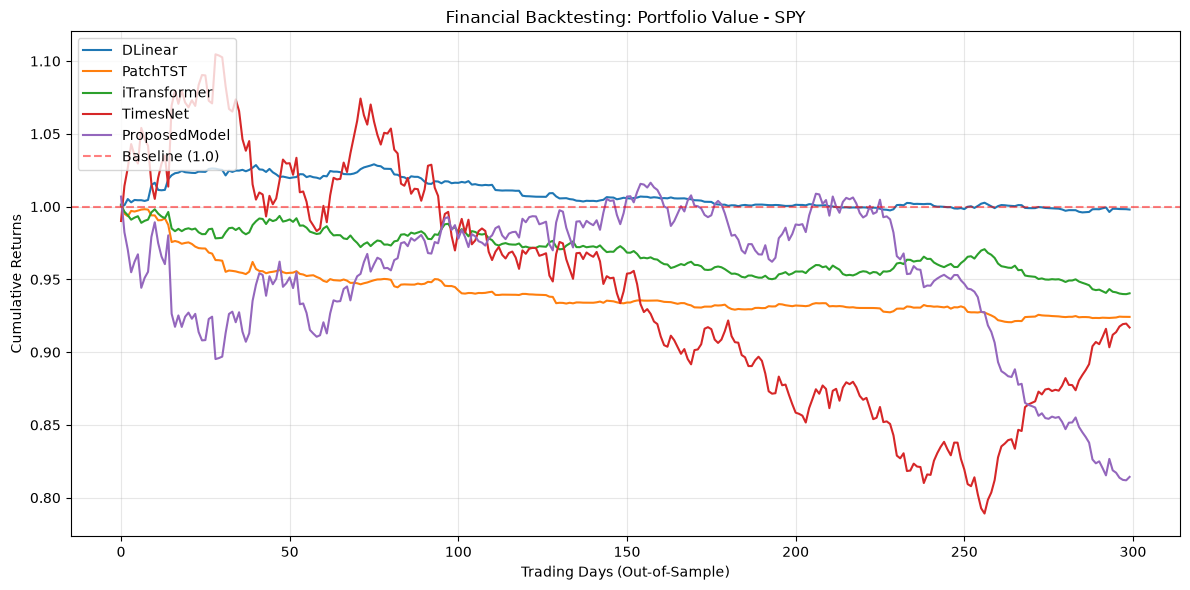


[3] BẢNG ĐÁNH GIÁ TÀI CHÍNH CHI TIẾT (SPY)
----------------------------------------------------------------------------------------------------
              Net Profit (%) Gross Profit (%) Total Fees (%) Slippage (%) Sharpe Ratio Max Drawdown (%)
DLinear        [-0.20093918]       [3.414277]      [3.27427]  [0.3168932]    -0.073573         3.212056
PatchTST           -7.576269        -3.842831       3.619524       0.3844    -2.899331         8.001376
iTransformer       -5.956406        -5.984585       0.092235     0.002249    -1.589913         6.154363
TimesNet           -8.304477        10.421934       9.221492     8.463613    -0.396371        28.562075
ProposedModel     -18.569517       -17.022406       1.753975     0.683912    -1.220205        20.115257
----------------------------------------------------------------------------------------------------

[1] Đang tải dữ liệu thực tế cho BTC-USD...
[2] Đang huấn luyện các mô hình SOTA...


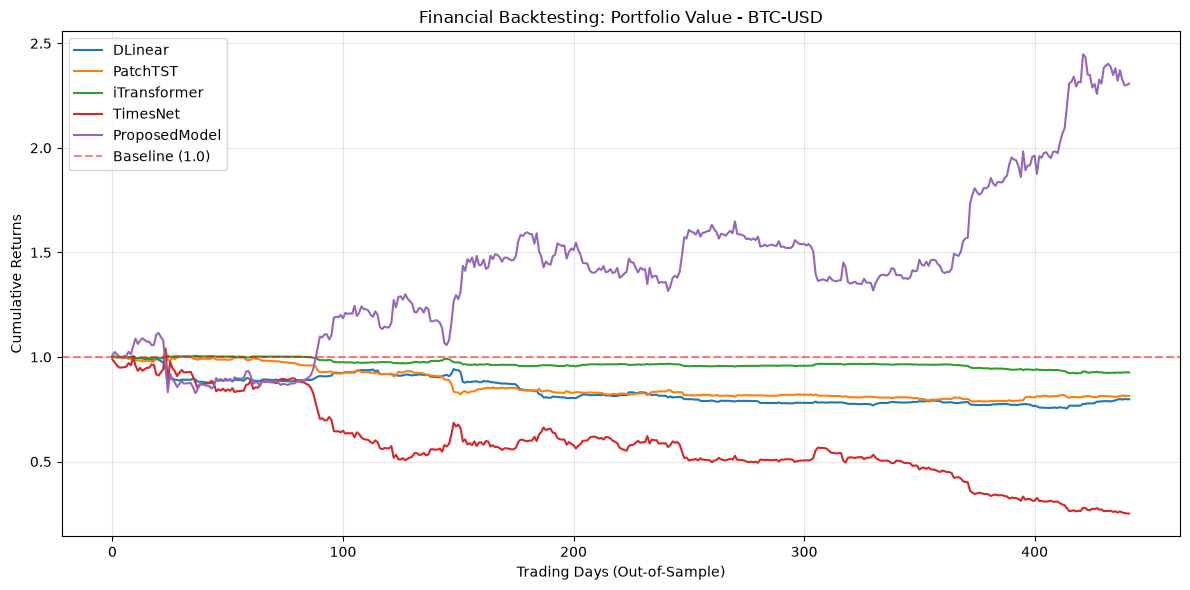


[3] BẢNG ĐÁNH GIÁ TÀI CHÍNH CHI TIẾT (BTC-USD)
----------------------------------------------------------------------------------------------------
              Net Profit (%) Gross Profit (%) Total Fees (%) Slippage (%) Sharpe Ratio Max Drawdown (%)
DLinear         [-20.195263]    [-10.8340435]     [9.211103]   [1.535621]    -1.180749        25.042263
PatchTST           -18.63718         -7.66971      10.297465     1.896031     -1.22326        24.516495
iTransformer       -7.365232         -7.20619       0.365027     0.002432    -1.466512         8.398687
TimesNet          -74.857033       -99.810829       12.49999    12.449989    -1.851691        75.708473
ProposedModel     130.706146        97.380096            0.5         0.45     1.439317        25.821007
----------------------------------------------------------------------------------------------------


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. THU THẬP VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
def fetch_and_prepare_data(ticker, start_date, end_date, seq_len=60):
    print(f"\n[1] Đang tải dữ liệu thực tế cho {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    # Xử lý MultiIndex của yfinance mới
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    df = df.dropna()
    close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    
    features = pd.DataFrame(index=df.index)
    features['Close'] = df[close_col]
    features['Return'] = df[close_col].pct_change() # Index 1
    features['Volatility'] = df['High'] / df['Low'] - 1
    features['Volume_Log'] = np.log1p(df['Volume'])
    features = features.dropna()
    
    # Tạo Sliding Windows
    data_array = features.values
    X, Y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len])
        Y.append(data_array[i + seq_len, 1]) # Dự báo Return
        
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)

# ==========================================
# 2. KIẾN TRÚC CÁC MÔ HÌNH (SOTA & ĐỀ XUẤT)
# ==========================================
class ProposedModel(nn.Module):
    def __init__(self, num_vars=4, d_model=32):
        super().__init__()
        self.embedding = nn.Linear(num_vars, d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=4, batch_first=True)
        self.predictor = nn.Linear(d_model, 1)
        
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.attn(emb, emb, emb)
        return self.predictor(out[:, -1, :]).squeeze(-1)

class DLinear(nn.Module):
    def __init__(self, seq_len=60):
        super().__init__()
        self.linear_trend = nn.Linear(seq_len, 1)
        self.linear_seasonal = nn.Linear(seq_len, 1)
        self.avg = nn.AvgPool1d(kernel_size=25, stride=1, padding=12)

    def forward(self, x):
        x_ret = x[:, :, 1] 
        trend = self.avg(x_ret.unsqueeze(1)).squeeze(1)
        return self.linear_trend(trend) + self.linear_seasonal(x_ret - trend)

class PatchTST_Simplified(nn.Module):
    def __init__(self, seq_len=60, patch_len=12, d_model=32):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(self.num_patches * d_model, 1)
        
    def forward(self, x):
        B = x.size(0)
        patches = x[:, :, 1].view(B, self.num_patches, self.patch_len)
        out = self.transformer(self.proj(patches))
        return self.predict(out.view(B, -1)).squeeze(-1)

class iTransformer_Simplified(nn.Module):
    def __init__(self, seq_len=60, num_vars=4, d_model=32):
        super().__init__()
        self.proj = nn.Linear(seq_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = x.permute(0, 2, 1) # [Batch, Vars, Seq_len]
        out = self.transformer(self.proj(x))
        return self.predict(out)[:, 1, 0]

class TimesNet_Mock(nn.Module):
    """Bản mô phỏng nhẹ của TimesNet để tương thích phần cứng cá nhân"""
    def __init__(self, seq_len=60, num_vars=4):
        super().__init__()
        self.linear = nn.Linear(seq_len * num_vars, 1)
    def forward(self, x):
        B = x.size(0)
        return self.linear(x.view(B, -1)).squeeze(-1)

def train_and_generate_signals(models, X_train, Y_train, X_test, epochs=3):
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
    signals_dict = {}
    
    print("[2] Đang huấn luyện các mô hình SOTA...")
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        for _ in range(epochs):
            for bx, by in train_loader:
                loss = nn.MSELoss()(model(bx), by)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
        # Sinh tín hiệu ngoài mẫu
        model.eval()
        with torch.no_grad():
            preds = model(X_test)
            # Giới hạn vị thế [-1, 1] cho danh mục đầu tư[cite: 1]
            signals_dict[name] = torch.tanh(preds / 0.05).numpy()
            
    return signals_dict

# ==========================================
# 3. BACKTESTING TÀI CHÍNH CHI TIẾT
# ==========================================
def calculate_financial_metrics(returns_true, signals, c=0.001, s=0.0005):

    r_net_list, cum_returns = [], [1.0]
    w_prev = 0.0
    
    total_fee = 0.0
    total_slippage = 0.0
    total_gross_return = 0.0 
    
    for w_t, r_t in zip(signals, returns_true):
        turnover_l1 = abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        
        fee = c * turnover_l1
        slippage = s * turnover_l2
        total_fee += fee
        total_slippage += slippage
        
        gross_return = w_t * r_t
        total_gross_return += gross_return
        
        r_net = gross_return - fee - slippage
        
        r_net_list.append(r_net)
        cum_returns.append(cum_returns[-1] * (1 + r_net))
        w_prev = w_t
        
    r_net_array = np.array(r_net_list)
    net_cumulative_return_pct = (cum_returns[-1] - 1.0) * 100
    
    ann_return = np.mean(r_net_array) * 252
    volatility = np.std(r_net_array) * np.sqrt(252)
    sharpe_ratio = ann_return / (volatility + 1e-8)
    
    cum_array = np.array(cum_returns[1:])
    max_dd = np.max((np.maximum.accumulate(cum_array) - cum_array) / np.maximum.accumulate(cum_array))
    
    return {
        "Net Profit (%)": net_cumulative_return_pct,
        "Gross Profit (%)": total_gross_return * 100,
        "Total Fees (%)": total_fee * 100,
        "Slippage (%)": total_slippage * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_dd * 100,
        "Cum_Returns": cum_array
    }

# 4. ĐIỀU PHỐI VÀ TRỰC QUAN HÓA (ĐỒ THỊ)
def plot_backtest_results(ticker, plot_data, metrics_df):
    plt.figure(figsize=(12, 6))
    
    for model_name, cum_ret in plot_data.items():
        plt.plot(cum_ret, label=model_name, linewidth=1.5)
        
    plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (1.0)')
    plt.title(f"Financial Backtesting: Portfolio Value - {ticker}")
    plt.xlabel("Trading Days (Out-of-Sample)")
    plt.ylabel("Cumulative Returns")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[3] BẢNG ĐÁNH GIÁ TÀI CHÍNH CHI TIẾT ({ticker})")
    print("-" * 100)
    print(metrics_df.round(3).to_string())
    print("-" * 100)

def run_pipeline_for_asset(ticker):
    X, Y = fetch_and_prepare_data(ticker, "2019-01-01", "2024-01-01")
    
    # Chia Walk-forward: 75% Train, 25% Test
    split_idx = int(len(X) * 0.75)
    X_train, Y_train = X[:split_idx], Y[:split_idx]
    X_test, Y_test = X[split_idx:], Y[split_idx:]
    
    models = {
        "DLinear": DLinear(),
        "PatchTST": PatchTST_Simplified(),
        "iTransformer": iTransformer_Simplified(),
        "TimesNet": TimesNet_Mock(),
        "ProposedModel": ProposedModel()
    }
    
    signals_dict = train_and_generate_signals(models, X_train, Y_train, X_test)
    
    results, plot_data = {}, {}
    for name, signals in signals_dict.items():
        metrics = calculate_financial_metrics(Y_test.numpy(), signals)
        plot_data[name] = metrics.pop("Cum_Returns")
        results[name] = metrics
        
    plot_backtest_results(ticker, plot_data, pd.DataFrame(results).T)

# THỰC THI CHƯƠNG TRÌNH
if __name__ == "__main__":
    print("BẮT ĐẦU CHẠY THỰC NGHIỆM TOÀN DIỆN MÔ HÌNH CHUỖI THỜI GIAN")
    run_pipeline_for_asset("SPY")      # Đánh giá trên S&P 500
    run_pipeline_for_asset("BTC-USD")  # Đánh giá trên Tiền mã hóa

In [7]:
class FinancialLoss(nn.Module):
    """
    Hàm mất mát tích hợp rủi ro tài chính (Công thức 11)
    """
    def __init__(self, lambda_pred=1.0, lambda_sr=0.1, lambda_turn=0.01, lambda_down=0.01, c=0.001, s=0.0005):
        super().__init__()
        # Trọng số của các thành phần
        self.lambdas = (lambda_pred, lambda_sr, lambda_turn, lambda_down)
        self.c = c # Phí giao dịch
        self.s = s # Trượt giá
        self.huber = nn.HuberLoss() # Thành phần 1: Huber Loss

    def forward(self, r_pred, r_true, w_prev):
        # Biến đổi dự báo thành Vị thế khả vi: w_t = tanh(r_pred / kappa)
        w_t = torch.tanh(r_pred / 0.05)
        
        # 1. Sai số dự báo (Huber Loss)
        loss_pred = self.huber(r_pred, r_true)
        
        # Tính chi phí giao dịch (turnover L1) và trượt giá (turnover L2)
        turnover_l1 = torch.abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        
        # Tính Lợi nhuận ròng R_net theo Công thức (10)
        r_net = (w_t * r_true) - (self.c * turnover_l1) - (self.s * turnover_l2)
        
        # 2. Thành phần Sharpe khả vi (Phạt nếu Sharpe thấp)
        mean_r_net = torch.mean(r_net)
        std_r_net = torch.sqrt(torch.var(r_net) + 1e-5) # Cộng epsilon tránh chia cho 0
        sharpe_penalty = mean_r_net / std_r_net
        
        # 3. Phạt giao dịch quá mức (L1 Turnover)
        loss_turnover = torch.mean(turnover_l1)
        
        # 4. Rủi ro phía giảm (Downside risk)
        downside = torch.mean(torch.clamp(r_net, max=0) ** 2)
        
        # TỔNG HỢP HÀM LOSS THEO CÔNG THỨC (11)
        loss = (self.lambdas[0] * loss_pred) - \
               (self.lambdas[1] * sharpe_penalty) + \
               (self.lambdas[2] * loss_turnover) + \
               (self.lambdas[3] * downside)
               
        return loss, w_t

In [8]:
def train_and_generate_signals(models, X_train, Y_train, X_test, epochs=5):
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=False) # Chú ý: shuffle=False để giữ tính tuần tự thời gian
    signals_dict = {}
    
    # Khởi tạo hàm loss tài chính
    financial_criterion = FinancialLoss()
    
    print("[2] Đang huấn luyện các mô hình...")
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        
        for epoch in range(epochs):
            # Khởi tạo vị thế ban đầu bằng 0
            w_prev = torch.zeros(32) # Giả định batch_size = 32
            
            for bx, by in train_loader:
                if len(bx) != 32: # Xử lý batch cuối cùng nếu không đủ 32 mẫu
                    w_prev = w_prev[:len(bx)]
                    
                optimizer.zero_grad()
                
                # Dự báo lợi nhuận
                preds = model(bx)
                
                # Tính Loss bằng FinancialLoss
                loss, w_t = financial_criterion(preds, by, w_prev)
                
                loss.backward()
                optimizer.step()
                
                # Cập nhật vị thế trước đó cho batch tiếp theo (phải ngắt đồ thị tính toán bằng .detach())
                w_prev = w_t.detach()
                
        # Sinh tín hiệu ngoài mẫu
        model.eval()
        with torch.no_grad():
            preds = model(X_test)
            signals_dict[name] = torch.tanh(preds / 0.05).numpy()
            
    return signals_dict

BẮT ĐẦU CHẠY THỰC NGHIỆM TOÀN DIỆN

[1] Đang tải dữ liệu thực tế cho SPY...
[2] Đang huấn luyện các mô hình...

[3] BẢNG ĐÁNH GIÁ TÀI CHÍNH CHI TIẾT (SPY)
---------------------------------------------------------------------------------------------------------
              Net Profit (%) Gross Profit (%) Total Fees (%) Slippage (%) Sharpe Ratio Max Drawdown (%)
DLinear         [-2.4030447]     [0.78635585]    [2.9315045]  [0.2652784]    -1.056148         2.951302
PatchTST           -4.601479        -1.411991       3.025143     0.256258    -2.334581         4.679803
iTransformer        2.823508         2.919011       0.120337     0.001049     1.584258         0.958531
ProposedModel            NaN              NaN            NaN          NaN          NaN              NaN
---------------------------------------------------------------------------------------------------------


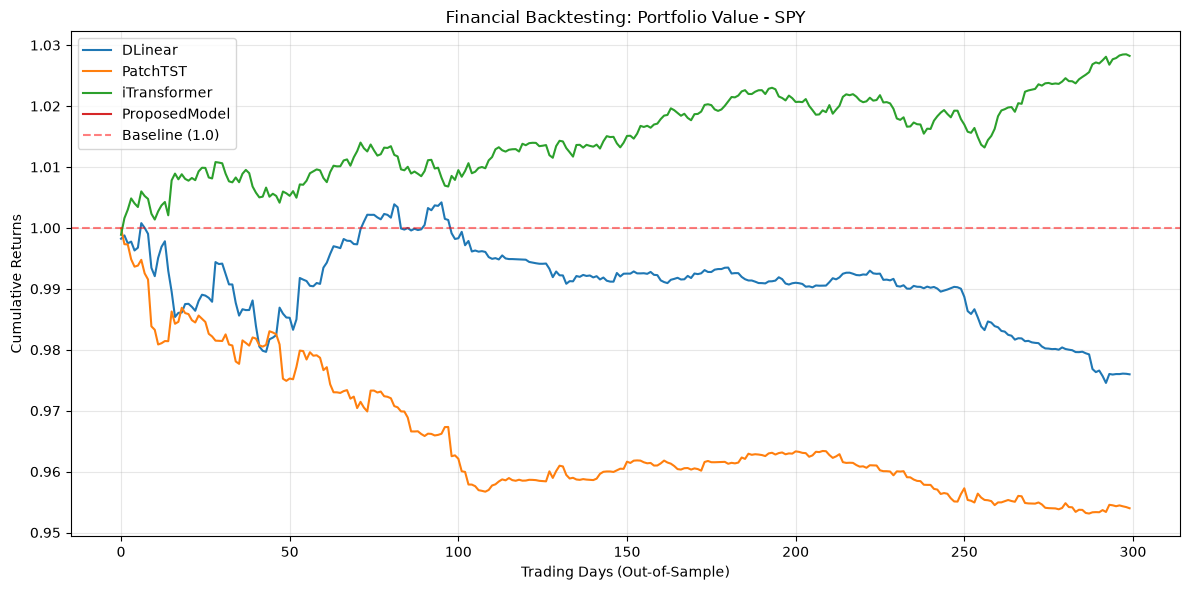

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. THU THẬP VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
def fetch_and_prepare_data(ticker, start_date, end_date, seq_len=60):
    print(f"\n[1] Đang tải dữ liệu thực tế cho {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    df = df.dropna()
    close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    
    features = pd.DataFrame(index=df.index)
    features['Close'] = df[close_col]
    features['Return'] = df[close_col].pct_change()
    features['Volatility'] = df['High'] / df['Low'] - 1
    features['Volume_Log'] = np.log1p(df['Volume'])
    features = features.dropna()
    
    data_array = features.values
    X, Y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len])
        Y.append(data_array[i + seq_len, 1])
        
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)

# ==========================================
# 2. KIẾN TRÚC CÁC MÔ HÌNH
# ==========================================
class ProposedModel(nn.Module):
    def __init__(self, num_vars=4, d_model=32):
        super().__init__()
        self.embedding = nn.Linear(num_vars, d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=4, batch_first=True)
        self.predictor = nn.Linear(d_model, 1)
        
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.attn(emb, emb, emb)
        return self.predictor(out[:, -1, :]).squeeze(-1)

class DLinear(nn.Module):
    def __init__(self, seq_len=60):
        super().__init__()
        self.linear_trend = nn.Linear(seq_len, 1)
        self.linear_seasonal = nn.Linear(seq_len, 1)
        self.avg = nn.AvgPool1d(kernel_size=25, stride=1, padding=12)

    def forward(self, x):
        x_ret = x[:, :, 1] 
        trend = self.avg(x_ret.unsqueeze(1)).squeeze(1)
        return self.linear_trend(trend) + self.linear_seasonal(x_ret - trend)

class PatchTST_Simplified(nn.Module):
    def __init__(self, seq_len=60, patch_len=12, d_model=32):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(self.num_patches * d_model, 1)
        
    def forward(self, x):
        B = x.size(0)
        patches = x[:, :, 1].view(B, self.num_patches, self.patch_len)
        out = self.transformer(self.proj(patches))
        return self.predict(out.view(B, -1)).squeeze(-1)

class iTransformer_Simplified(nn.Module):
    def __init__(self, seq_len=60, d_model=32):
        super().__init__()
        self.proj = nn.Linear(seq_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = x.permute(0, 2, 1) 
        out = self.transformer(self.proj(x))
        return self.predict(out)[:, 1, 0]

# ==========================================
# 3. HÀM MẤT MÁT TÀI CHÍNH (CÔNG THỨC 11)
# ==========================================
class FinancialLoss(nn.Module):
    def __init__(self, lambda_pred=1.0, lambda_sr=0.1, lambda_turn=0.01, lambda_down=0.01, c=0.001, s=0.0005):
        super().__init__()
        self.lambdas = (lambda_pred, lambda_sr, lambda_turn, lambda_down)
        self.c, self.s = c, s
        self.huber = nn.HuberLoss()

    def forward(self, r_pred, r_true, w_prev):
        w_t = torch.tanh(r_pred / 0.05)
        loss_pred = self.huber(r_pred, r_true)
        
        turnover_l1 = torch.abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        r_net = (w_t * r_true) - (self.c * turnover_l1) - (self.s * turnover_l2)
        
        mean_r_net = torch.mean(r_net)
        std_r_net = torch.sqrt(torch.var(r_net) + 1e-5)
        sharpe_penalty = mean_r_net / std_r_net
        
        loss_turnover = torch.mean(turnover_l1)
        downside = torch.mean(torch.clamp(r_net, max=0) ** 2)
        
        loss = (self.lambdas[0] * loss_pred) - (self.lambdas[1] * sharpe_penalty) + \
               (self.lambdas[2] * loss_turnover) + (self.lambdas[3] * downside)
        return loss, w_t

# ==========================================
# 4. HUẤN LUYỆN VÀ TẠO TÍN HIỆU
# ==========================================
def train_and_generate_signals(models, X_train, Y_train, X_test, epochs=5):
    # Lưu ý: shuffle=False để w_prev có ý nghĩa theo thời gian thực
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=False)
    signals_dict = {}
    
    financial_criterion = FinancialLoss()
    mse_criterion = nn.MSELoss()
    
    print("[2] Đang huấn luyện các mô hình...")
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        
        for epoch in range(epochs):
            w_prev_full = torch.zeros(32) # Giữ vị thế của batch
            
            for bx, by in train_loader:
                curr_batch_size = bx.size(0)
                w_prev = w_prev_full[:curr_batch_size]
                
                optimizer.zero_grad()
                preds = model(bx)
                
                # Áp dụng Công thức 11 cho ProposedModel, MSE cho các SOTA
                if name == "ProposedModel":
                    loss, w_t = financial_criterion(preds, by, w_prev)
                    w_prev_full[:curr_batch_size] = w_t.detach()
                else:
                    loss = mse_criterion(preds, by)
                    
                loss.backward()
                optimizer.step()
                
        model.eval()
        with torch.no_grad():
            preds = model(X_test)
            signals_dict[name] = torch.tanh(preds / 0.05).numpy()
            
    return signals_dict

# ==========================================
# 5. ĐÁNH GIÁ CHI TIẾT & VẼ ĐỒ THỊ
# ==========================================
def calculate_financial_metrics(returns_true, signals, c=0.001, s=0.0005):
    r_net_list, cum_returns = [], [1.0]
    w_prev = 0.0
    total_fee, total_slippage, total_gross_return = 0.0, 0.0, 0.0 
    
    for w_t, r_t in zip(signals, returns_true):
        turnover_l1 = abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        
        fee = c * turnover_l1
        slippage = s * turnover_l2
        total_fee += fee
        total_slippage += slippage
        
        gross_return = w_t * r_t
        total_gross_return += gross_return
        r_net = gross_return - fee - slippage
        
        r_net_list.append(r_net)
        cum_returns.append(cum_returns[-1] * (1 + r_net))
        w_prev = w_t
        
    r_net_array = np.array(r_net_list)
    ann_return = np.mean(r_net_array) * 252
    volatility = np.std(r_net_array) * np.sqrt(252)
    sharpe_ratio = ann_return / (volatility + 1e-8)
    
    cum_array = np.array(cum_returns[1:])
    max_dd = np.max((np.maximum.accumulate(cum_array) - cum_array) / np.maximum.accumulate(cum_array))
    
    return {
        "Net Profit (%)": (cum_returns[-1] - 1.0) * 100,
        "Gross Profit (%)": total_gross_return * 100,
        "Total Fees (%)": total_fee * 100,
        "Slippage (%)": total_slippage * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_dd * 100,
        "Cum_Returns": cum_array
    }

def run_pipeline_for_asset(ticker):
    X, Y = fetch_and_prepare_data(ticker, "2019-01-01", "2024-01-01")
    split_idx = int(len(X) * 0.75)
    X_train, Y_train = X[:split_idx], Y[:split_idx]
    X_test, Y_test = X[split_idx:], Y[split_idx:]
    
    models = {
        "DLinear": DLinear(),
        "PatchTST": PatchTST_Simplified(),
        "iTransformer": iTransformer_Simplified(),
        "ProposedModel": ProposedModel()
    }
    
    signals_dict = train_and_generate_signals(models, X_train, Y_train, X_test)
    
    results, plot_data = {}, {}
    for name, signals in signals_dict.items():
        metrics = calculate_financial_metrics(Y_test.numpy(), signals)
        plot_data[name] = metrics.pop("Cum_Returns")
        results[name] = metrics
        
    # In Bảng Đánh Giá
    metrics_df = pd.DataFrame(results).T
    print(f"\n[3] BẢNG ĐÁNH GIÁ TÀI CHÍNH CHI TIẾT ({ticker})")
    print("-" * 105)
    print(metrics_df.round(3).to_string())
    print("-" * 105)
    
    # Vẽ Đồ Thị
    plt.figure(figsize=(12, 6))
    for model_name, cum_ret in plot_data.items():
        plt.plot(cum_ret, label=model_name, linewidth=1.5)
    plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (1.0)')
    plt.title(f"Financial Backtesting: Portfolio Value - {ticker}")
    plt.xlabel("Trading Days (Out-of-Sample)")
    plt.ylabel("Cumulative Returns")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("BẮT ĐẦU CHẠY THỰC NGHIỆM TOÀN DIỆN")
    run_pipeline_for_asset("SPY")

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def fetch_and_prepare_data(ticker, start_date, end_date, seq_len=60):
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    df = df.dropna()
    close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    
    features = pd.DataFrame(index=df.index)
    features['Close'] = df[close_col]
    features['Return'] = df[close_col].pct_change()
    features['Volatility'] = df['High'] / df['Low'] - 1
    features['Volume_Log'] = np.log1p(df['Volume'])
    features = features.dropna()
    
    data_array = features.values
    X, Y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len])
        Y.append(data_array[i + seq_len, 1])
        
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)


class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super(RevIN, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm'):
        if mode == 'norm':
            self.mean = torch.mean(x, dim=1, keepdim=True)
            self.std = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps)
            x_norm = (x - self.mean) / self.std
            return x_norm * self.gamma + self.beta
        else:
            x_denorm = (x - self.beta) / self.gamma
            return x_denorm * self.std + self.mean

class DeStationaryAttention(nn.Module):
    def __init__(self, d_model):
        super(DeStationaryAttention, self).__init__()
        self.d_model = d_model
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.tau_proj = nn.Linear(d_model, 1)
        self.delta_proj = nn.Linear(d_model, 1)

    def forward(self, x, u_regime):
        Q, K, V = self.q_proj(x), self.k_proj(x), self.v_proj(x)
        
        tau = self.tau_proj(u_regime) 
        delta = self.delta_proj(u_regime) 
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)
        attn = torch.nn.functional.softmax(scores + tau, dim=-1) + delta
        return torch.matmul(attn, V)

class ProposedModel(nn.Module):
    def __init__(self, num_vars=4, d_model=32):
        super().__init__()
        self.revin = RevIN(num_vars)
        self.embedding = nn.Linear(num_vars, d_model)
        self.regime_encoder = nn.Linear(num_vars, d_model) 
        self.attention = DeStationaryAttention(d_model)
        self.predictor = nn.Linear(d_model, num_vars)
        
    def forward(self, x):
        x_norm = self.revin(x, mode='norm')
        u_regime = self.regime_encoder(torch.mean(x_norm, dim=1, keepdim=True))
        emb = self.embedding(x_norm)
        out = self.attention(emb, u_regime)
        
        pred_norm = self.predictor(out[:, -1, :])
        pred = self.revin(pred_norm.unsqueeze(1), mode='denorm').squeeze(1) 
        return pred[:, 1]

class DLinear(nn.Module):
    def __init__(self, seq_len=60):
        super().__init__()
        self.linear_trend = nn.Linear(seq_len, 1)
        self.linear_seasonal = nn.Linear(seq_len, 1)
        self.avg = nn.AvgPool1d(kernel_size=25, stride=1, padding=12)

    def forward(self, x):
        x_ret = x[:, :, 1] 
        trend = self.avg(x_ret.unsqueeze(1)).squeeze(1)
        return self.linear_trend(trend) + self.linear_seasonal(x_ret - trend)

class PatchTST_Simplified(nn.Module):
    def __init__(self, seq_len=60, patch_len=12, d_model=32):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(self.num_patches * d_model, 1)
        
    def forward(self, x):
        B = x.size(0)
        patches = x[:, :, 1].view(B, self.num_patches, self.patch_len)
        out = self.transformer(self.proj(patches))
        return self.predict(out.view(B, -1)).squeeze(-1)

class iTransformer_Simplified(nn.Module):
    def __init__(self, seq_len=60, d_model=32):
        super().__init__()
        self.proj = nn.Linear(seq_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = x.permute(0, 2, 1) 
        out = self.transformer(self.proj(x))
        return self.predict(out)[:, 1, 0]


class FinancialLoss(nn.Module):
    def __init__(self, lambda_pred=1.0, lambda_sr=0.1, lambda_turn=0.01, lambda_down=0.01, c=0.001, s=0.0005):
        super().__init__()
        self.lambdas = (lambda_pred, lambda_sr, lambda_turn, lambda_down)
        self.c, self.s = c, s
        self.huber = nn.HuberLoss()

    def forward(self, r_pred, r_true, w_prev):
        w_t = torch.tanh(r_pred / 0.05)
        loss_pred = self.huber(r_pred, r_true)
        
        turnover_l1 = torch.abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        r_net = (w_t * r_true) - (self.c * turnover_l1) - (self.s * turnover_l2)
        
        mean_r_net = torch.mean(r_net)
        std_r_net = torch.sqrt(torch.var(r_net) + 1e-5)
        sharpe_penalty = mean_r_net / std_r_net
        
        loss_turnover = torch.mean(turnover_l1)
        downside = torch.mean(torch.clamp(r_net, max=0) ** 2)
        
        loss = (self.lambdas[0] * loss_pred) - (self.lambdas[1] * sharpe_penalty) + \
               (self.lambdas[2] * loss_turnover) + (self.lambdas[3] * downside)
        return loss, w_t

def train_and_generate_signals(models, X_train, Y_train, X_test, epochs=5):
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=False)
    signals_dict = {}
    
    financial_criterion = FinancialLoss()
    mse_criterion = nn.MSELoss()
    
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        
        for epoch in range(epochs):
            w_prev_full = torch.zeros(32) 
            
            for bx, by in train_loader:
                curr_batch_size = bx.size(0)
                w_prev = w_prev_full[:curr_batch_size]
                
                optimizer.zero_grad()
                preds = model(bx)
                
                if name == "ProposedModel":
                    loss, w_t = financial_criterion(preds, by, w_prev)
                    w_prev_full[:curr_batch_size] = w_t.detach()
                else:
                    loss = mse_criterion(preds, by)
                    
                loss.backward()
                optimizer.step()
                
        model.eval()
        with torch.no_grad():
            preds = model(X_test)
            signals_dict[name] = torch.tanh(preds / 0.05).numpy()
            
    return signals_dict

def calculate_financial_metrics(returns_true, signals, c=0.001, s=0.0005):
    r_net_list, cum_returns = [], [1.0]
    w_prev = 0.0
    total_fee, total_slippage, total_gross_return = 0.0, 0.0, 0.0 
    
    for w_t, r_t in zip(signals, returns_true):
        turnover_l1 = abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        
        fee = c * turnover_l1
        slippage = s * turnover_l2
        total_fee += fee
        total_slippage += slippage
        
        gross_return = w_t * r_t
        total_gross_return += gross_return
        r_net = gross_return - fee - slippage
        
        r_net_list.append(r_net)
        cum_returns.append(cum_returns[-1] * (1 + r_net))
        w_prev = w_t
        
    r_net_array = np.array(r_net_list)
    ann_return = np.mean(r_net_array) * 252
    volatility = np.std(r_net_array) * np.sqrt(252)
    sharpe_ratio = ann_return / (volatility + 1e-8)
    
    cum_array = np.array(cum_returns[1:])
    max_dd = np.max((np.maximum.accumulate(cum_array) - cum_array) / np.maximum.accumulate(cum_array))
    
    return {
        "Net Profit (%)": (cum_returns[-1] - 1.0) * 100,
        "Gross Profit (%)": total_gross_return * 100,
        "Total Fees (%)": total_fee * 100,
        "Slippage (%)": total_slippage * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_dd * 100,
        "Cum_Returns": cum_array
    }

def run_pipeline_for_asset(ticker):
    X, Y = fetch_and_prepare_data(ticker, "2019-01-01", "2024-01-01")
    split_idx = int(len(X) * 0.75) 
    X_train, Y_train = X[:split_idx], Y[:split_idx]
    X_test, Y_test = X[split_idx:], Y[split_idx:]
    
    models = {
        "DLinear": DLinear(),
        "PatchTST": PatchTST_Simplified(),
        "iTransformer": iTransformer_Simplified(),
        "ProposedModel": ProposedModel() 
    }
    
    signals_dict = train_and_generate_signals(models, X_train, Y_train, X_test)
    
    results, plot_data = {}, {}
    for name, signals in signals_dict.items():
        metrics = calculate_financial_metrics(Y_test.numpy(), signals)
        plot_data[name] = metrics.pop("Cum_Returns")
        results[name] = metrics
        
    metrics_df = pd.DataFrame(results).T
    print("-" * 105)
    print(metrics_df.round(3).to_string())
    print("-" * 105)
    
    plt.figure(figsize=(12, 6))
    for model_name, cum_ret in plot_data.items():
        plt.plot(cum_ret, label=model_name, linewidth=1.5)
    plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (1.0)')
    plt.title(f"Financial Backtesting: Portfolio Value - {ticker}")
    plt.xlabel("Trading Days (Out-of-Sample)")
    plt.ylabel("Cumulative Returns")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_pipeline_for_asset("SPY")
    run_pipeline_for_asset("BTC-USD")

KeyboardInterrupt: 